# 🚁 AIC 2026 — Disaster Vehicle Tracking via UAV
### Siamese Network + MobileNetV2 + Depth-wise Cross-Correlation

---

**Competition:** AIC 2026 — Emergency Vehicle Tracking (Ambulances/Cars) in Disaster Scenarios  
**Task:** Single-Object Tracking (SOT) using UAV aerial footage  
**Constraints:** Model < 40 MB | Parameters < 10M | Edge-AI Target: < 1 MB / ~500k params  

---

## 📋 Notebook Structure
1. [Environment Setup & Imports](#1)
2. [Configuration](#2)
3. [Data Engineering — Dataset & Augmentation](#3)
4. [Architecture — Siamese Network](#4)
5. [Training Loop](#5)
6. [Evaluation — Calibrated Accuracy](#6)
7. [Visual Check](#7)
8. [ONNX Export](#8)
9. [Submission Generation](#9)

<a id='1'></a>
## 1 — Environment Setup & Imports

**[AR] ما بنعمله هنا:**  
بنستورد كل المكتبات اللي محتاجينها: PyTorch للنموذج، torchvision للـ backbone، OpenCV لمعالجة الصور، onnx لتصدير النموذج، وباقي الأدوات المساعدة.

In [2]:
# ── Install packages not pre-installed on Kaggle ──────────────────────────────
import subprocess, sys

def pip_install(pkg: str):
    """Install a pip package quietly and print result."""
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f"{status} {pkg}")
    if result.returncode != 0:
        print(result.stderr[-300:])

# onnxruntime-gpu → falls back to CPU automatically if no CUDA
pip_install('onnxruntime-gpu')
pip_install('onnx')

print("\nAll dependencies ready.")

✅ onnxruntime-gpu
✅ onnx

All dependencies ready.


In [3]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import random
import time
import warnings
from pathlib import Path

# ── Numerical & Image ─────────────────────────────────────────────────────────
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ── ONNX Export ───────────────────────────────────────────────────────────────
import onnx
import onnxruntime as ort

# ── Misc ──────────────────────────────────────────────────────────────────────
import pandas as pd
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility seed ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print(f"PyTorch  : {torch.__version__}")
print(f"ONNX     : {onnx.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")

PyTorch  : 2.10.0+cu128
ONNX     : 1.20.1
CUDA avail: True


<a id='2'></a>
## 2 — Configuration

**[AR] ما بنعمله هنا:**  
بنحدد كل الـ hyperparameters في مكان واحد (Config class) علشان يكون سهل نغيرها. بنحدد حجم الـ template وال search region، معدل التعلم، عدد الـ epochs، وباقي الإعدادات.

In [15]:
import os
import cv2
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ── Step 1: Index all vehicle videos from the dataset ─────────────────────────
def index_vehicle_data(dataset_root: str) -> list:
    """
    Walk /kaggle/input, find folders with vehicle keywords that contain
    both a video file and an annotation txt/csv.
    """
    vehicle_keywords = ['car', 'motorcycle', 'truck', 'vehicle',
                        'ambulance', 'bus', 'van']
    video_exts  = ('.mp4', '.avi', '.mkv', '.mov')
    valid_list  = []

    for dirpath, _, filenames in os.walk(dataset_root):
        folder_name = os.path.basename(dirpath).lower()
        if not any(kw in folder_name for kw in vehicle_keywords):
            continue
        videos = sorted([f for f in filenames if f.lower().endswith(video_exts)])
        annots = sorted([f for f in filenames if f.lower().endswith(('.txt', '.csv'))])
        if videos and annots:
            valid_list.append({
                'video_path': os.path.join(dirpath, videos[0]),
                'ann_path':   os.path.join(dirpath, annots[0]),
            })

    print(f"[INFO] Found {len(valid_list)} valid vehicle videos.")
    return valid_list


all_data   = index_vehicle_data('/kaggle/input')
random.shuffle(all_data)
split_idx  = int(0.8 * len(all_data))
train_data = all_data[:split_idx]
val_data   = all_data[split_idx:]
print(f"  Train: {len(train_data)} | Val: {len(val_data)}")


# ── Step 2: Dataset class ─────────────────────────────────────────────────────
class VehicleTrackingDataset(Dataset):
    """
    Reads videos directly with OpenCV.
    Frame 0  → Template (z) : 127×127
    Random future frame → Search Region (x) : 255×255
    Gaussian heatmap centred → Ground Truth
    """

    def __init__(self, data_list: list, cfg, augment: bool = True):
        self.data_list    = data_list
        self.cfg          = cfg
        self.augment      = augment
        self.disaster_aug = DisasterAugmentation(cfg) if augment else None

        self.to_tensor_z = transforms.Compose([
            transforms.Resize((cfg.TEMPLATE_SIZE, cfg.TEMPLATE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        self.to_tensor_x = transforms.Compose([
            transforms.Resize((cfg.SEARCH_SIZE, cfg.SEARCH_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.data_list)

    @staticmethod
    def _parse_bbox(ann_path: str) -> tuple:
        """Read first valid bbox line → (x, y, w, h)."""
        with open(ann_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or any(c.isalpha() for c in line):
                    continue
                parts = line.split(',') if ',' in line else line.split()
                coords = parts[-4:] if len(parts) >= 5 else parts[:4]
                if len(coords) == 4:
                    return tuple(max(0, int(float(v))) for v in coords)
        return (0, 0, 64, 64)   # safe fallback

    @staticmethod
    def _safe_crop(frame_rgb: np.ndarray, x, y, w, h) -> np.ndarray:
        """Crop bbox from frame; return small black patch if crop is empty."""
        ih, iw = frame_rgb.shape[:2]
        x  = min(x, iw - 1);  y  = min(y, ih - 1)
        w  = max(1, min(w, iw - x));  h = max(1, min(h, ih - y))
        crop = frame_rgb[y:y+h, x:x+w]
        return crop if crop.size > 0 else np.zeros((64, 64, 3), dtype=np.uint8)

    @staticmethod
    def _gaussian_heatmap(size: int, sigma: float = 1.5) -> torch.Tensor:
        cx, cy = size // 2, size // 2
        xs, ys = np.meshgrid(np.arange(size), np.arange(size))
        hm = np.exp(-((xs-cx)**2 + (ys-cy)**2) / (2*sigma**2))
        hm = (hm / hm.max()).astype(np.float32)
        return torch.from_numpy(hm).unsqueeze(0)   # 1×size×size

    def __getitem__(self, idx):
        item = self.data_list[idx % len(self.data_list)]

        # ── Open video ────────────────────────────────────────────────────────
        cap          = cv2.VideoCapture(item['video_path'])
        total_frames = max(2, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

        # ── Template: frame 0 ─────────────────────────────────────────────────
        ret0, frame0 = cap.read()
        if not ret0:
            cap.release()
            return self.__getitem__((idx + 1) % len(self.data_list))
        frame0_rgb   = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
        x, y, w, h  = self._parse_bbox(item['ann_path'])
        tmpl_crop    = self._safe_crop(frame0_rgb, x, y, w, h)

        # ── Search region: random future frame ───────────────────────────────
        srch_idx = random.randint(min(5, total_frames-1), total_frames-1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, srch_idx)
        ret1, srch_frame = cap.read()
        cap.release()

        srch_rgb = cv2.cvtColor(srch_frame, cv2.COLOR_BGR2RGB) \
                   if ret1 else frame0_rgb.copy()

        # ── Disaster augmentation on search region ────────────────────────────
        if self.augment and self.disaster_aug:
            srch_rgb = self.disaster_aug(srch_rgb)

        # ── Convert to tensors ────────────────────────────────────────────────
        z       = self.to_tensor_z(Image.fromarray(tmpl_crop))   # 3×127×127
        x_srch  = self.to_tensor_x(Image.fromarray(srch_rgb))    # 3×255×255
        heatmap = self._gaussian_heatmap(self.cfg.HEATMAP_SIZE)  # 1×9×9

        return z, x_srch, heatmap


# ── Instantiate loaders ───────────────────────────────────────────────────────
train_dataset = VehicleTrackingDataset(train_data, cfg, augment=True)
val_dataset   = VehicleTrackingDataset(val_data,   cfg, augment=False)

train_loader  = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                           shuffle=True,  num_workers=cfg.NUM_WORKERS,
                           pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE,
                           shuffle=False, num_workers=cfg.NUM_WORKERS,
                           pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")

[INFO] Found 95 valid vehicle videos.
  Train: 76 | Val: 19
Train samples : 76
Val   samples : 19
Train batches : 5


<a id='3'></a>
## 3 — Data Engineering

### 3.1 — Disaster Augmentation Pipeline

**[AR] ما بنعمله هنا:**  
بنبني pipeline خاص لمحاكاة ظروف الكوارث:
- **Gaussian Blur**: يمثل اهتزاز الكاميرا عند الطائرة بدون طيار
- **Fog Simulation**: يضيف طبقة ضباب/دخان على الصورة بدرجات مختلفة
- **Salt & Pepper Noise**: يضيف تشويش عشوائي يمثل تداخل الإشارة في الكوارث

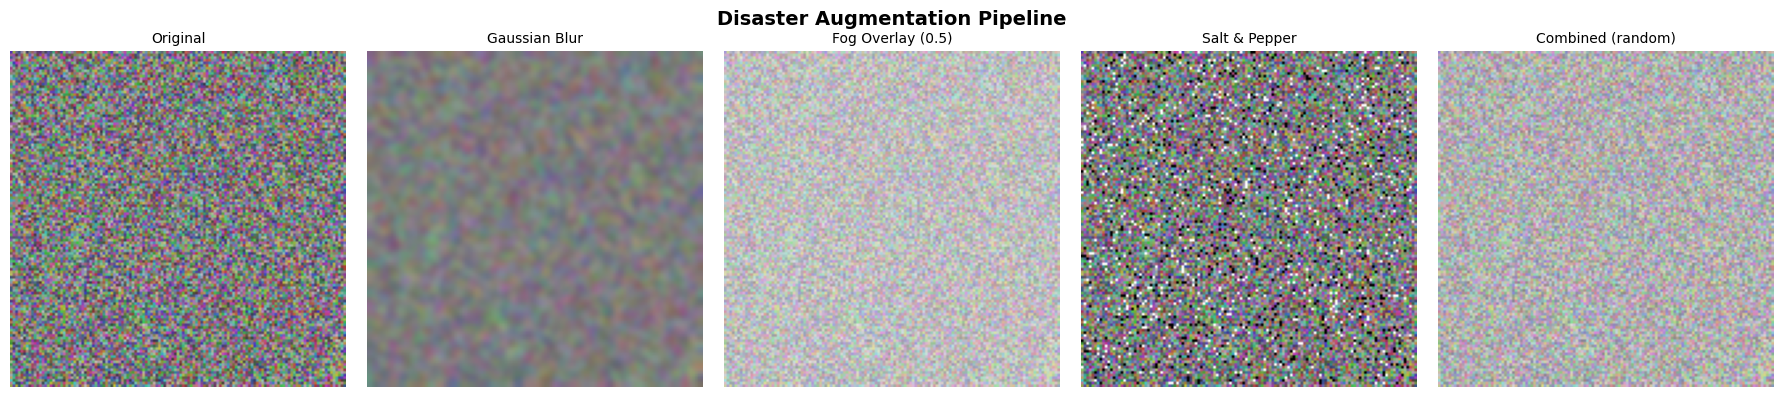

In [16]:
class DisasterAugmentation:
    """
    Custom augmentation pipeline simulating disaster conditions:
    smoke, fog, camera vibration, and sensor noise.
    All transforms accept and return uint8 numpy images (H×W×3).
    """

    def __init__(self, cfg: Config):
        self.blur_prob  = cfg.AUG_BLUR_PROB
        self.fog_prob   = cfg.AUG_FOG_PROB
        self.noise_prob = cfg.AUG_NOISE_PROB

    # ── Individual transforms ─────────────────────────────────────────────────

    @staticmethod
    def gaussian_blur(img: np.ndarray, severity: int = None) -> np.ndarray:
        """Simulates camera vibration via Gaussian blur."""
        if severity is None:
            severity = random.choice([3, 5, 7])  # kernel sizes
        return cv2.GaussianBlur(img, (severity, severity), 0)

    @staticmethod
    def fog_overlay(img: np.ndarray, intensity: float = None) -> np.ndarray:
        """Simulates smoke/fog by blending with a white haze layer."""
        if intensity is None:
            intensity = random.uniform(0.2, 0.6)  # fog strength
        fog_layer = np.ones_like(img, dtype=np.float32) * 255.0
        foggy = cv2.addWeighted(
            img.astype(np.float32), 1.0 - intensity,
            fog_layer,              intensity,
            0
        )
        return np.clip(foggy, 0, 255).astype(np.uint8)

    @staticmethod
    def salt_pepper_noise(img: np.ndarray, amount: float = None) -> np.ndarray:
        """Adds salt-and-pepper noise simulating sensor interference."""
        if amount is None:
            amount = random.uniform(0.01, 0.05)
        out = img.copy()
        num_pixels = img.size // 3
        # Salt (white pixels)
        salt_idx = [np.random.randint(0, d - 1, int(num_pixels * amount))
                    for d in img.shape[:2]]
        out[salt_idx[0], salt_idx[1]] = 255
        # Pepper (black pixels)
        pepper_idx = [np.random.randint(0, d - 1, int(num_pixels * amount))
                      for d in img.shape[:2]]
        out[pepper_idx[0], pepper_idx[1]] = 0
        return out

    # ── Combined pipeline ─────────────────────────────────────────────────────

    def __call__(self, img: np.ndarray) -> np.ndarray:
        """Apply augmentations stochastically based on configured probabilities."""
        if random.random() < self.blur_prob:
            img = self.gaussian_blur(img)
        if random.random() < self.fog_prob:
            img = self.fog_overlay(img)
        if random.random() < self.noise_prob:
            img = self.salt_pepper_noise(img)
        return img


# ── Visualise the augmentation effects ────────────────────────────────────────
def visualize_augmentations(sample_img_path: str = None):
    """Show effect of each disaster augmentation on a sample patch."""
    # Create a synthetic grey patch if no real image is provided
    if sample_img_path and Path(sample_img_path).exists():
        img = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (127, 127))
    else:
        img = np.random.randint(50, 200, (127, 127, 3), dtype=np.uint8)

    aug = DisasterAugmentation(cfg)
    transforms_list = [
        ('Original',            img),
        ('Gaussian Blur',       aug.gaussian_blur(img.copy(), 7)),
        ('Fog Overlay (0.5)',   aug.fog_overlay(img.copy(), 0.5)),
        ('Salt & Pepper',       aug.salt_pepper_noise(img.copy(), 0.04)),
        ('Combined (random)',   aug(img.copy())),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle('Disaster Augmentation Pipeline', fontsize=14, fontweight='bold')
    for ax, (title, patch) in zip(axes, transforms_list):
        ax.imshow(patch)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_augmentations()

### 3.2 — Custom Dataset Class

**[AR] ما بنعمله هنا:**  
بنبني الـ Dataset اللي بيقرأ البيانات ويجهزها للتدريب. كل عينة بتتكون من:
- **Template (z)**: صورة صغيرة للهدف (السيارة/الإسعاف) من frame سابق
- **Search Region (x)**: منطقة بحث أكبر من الـ frame الحالي
- **Gaussian Heatmap**: خريطة حرارية تحدد مكان الهدف في منطقة البحث (هي الـ ground truth)

In [19]:
import os, cv2, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ── Index vehicle videos ──────────────────────────────────────────────────────
def index_vehicle_data(dataset_root: str) -> list:
    vehicle_keywords = ['car', 'motorcycle', 'truck', 'vehicle',
                        'ambulance', 'bus', 'van']
    video_exts = ('.mp4', '.avi', '.mkv', '.mov')
    valid_list = []
    for dirpath, _, filenames in os.walk(dataset_root):
        folder_name = os.path.basename(dirpath).lower()
        if not any(kw in folder_name for kw in vehicle_keywords):
            continue
        videos = sorted([f for f in filenames if f.lower().endswith(video_exts)])
        annots = sorted([f for f in filenames if f.lower().endswith(('.txt', '.csv'))])
        if videos and annots:
            valid_list.append({
                'video_path': os.path.join(dirpath, videos[0]),
                'ann_path':   os.path.join(dirpath, annots[0]),
            })
    print(f"[INFO] Found {len(valid_list)} valid vehicle videos.")
    return valid_list

all_data  = index_vehicle_data('/kaggle/input')
random.shuffle(all_data)
n         = int(0.8 * len(all_data))
train_data = all_data[:n]
val_data   = all_data[n:]
print(f"  Train: {len(train_data)} | Val: {len(val_data)}")


# ── Dataset class (video-based) ───────────────────────────────────────────────
class VehicleTrackingDataset(Dataset):

    def __init__(self, data_list: list, cfg, augment: bool = True):
        self.data_list    = data_list
        self.cfg          = cfg
        self.augment      = augment
        self.disaster_aug = DisasterAugmentation(cfg) if augment else None
        self.to_tensor_z  = transforms.Compose([
            transforms.Resize((cfg.TEMPLATE_SIZE, cfg.TEMPLATE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
        self.to_tensor_x  = transforms.Compose([
            transforms.Resize((cfg.SEARCH_SIZE, cfg.SEARCH_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

    def __len__(self): return len(self.data_list)

    @staticmethod
    def _parse_bbox(ann_path):
        with open(ann_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or any(c.isalpha() for c in line): continue
                parts = line.split(',') if ',' in line else line.split()
                coords = parts[-4:] if len(parts) >= 5 else parts[:4]
                if len(coords) == 4:
                    return tuple(max(0, int(float(v))) for v in coords)
        return (0, 0, 64, 64)

    @staticmethod
    def _safe_crop(frame, x, y, w, h):
        ih, iw = frame.shape[:2]
        x=min(x,iw-1); y=min(y,ih-1)
        w=max(1,min(w,iw-x)); h=max(1,min(h,ih-y))
        crop = frame[y:y+h, x:x+w]
        return crop if crop.size > 0 else np.zeros((64,64,3), dtype=np.uint8)

    @staticmethod
    def _gaussian_heatmap(size, sigma=1.5):
        cx=cy=size//2
        xs,ys = np.meshgrid(np.arange(size), np.arange(size))
        hm = np.exp(-((xs-cx)**2+(ys-cy)**2)/(2*sigma**2))
        return torch.from_numpy((hm/hm.max()).astype(np.float32)).unsqueeze(0)

    def __getitem__(self, idx):
        item = self.data_list[idx % len(self.data_list)]
        cap  = cv2.VideoCapture(item['video_path'])
        total = max(2, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
        ret0, frame0 = cap.read()
        if not ret0:
            cap.release()
            return self.__getitem__((idx+1) % len(self.data_list))
        frame0_rgb  = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
        x,y,w,h    = self._parse_bbox(item['ann_path'])
        tmpl_crop  = self._safe_crop(frame0_rgb, x, y, w, h)
        srch_idx   = random.randint(min(5, total-1), total-1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, srch_idx)
        ret1, srch  = cap.read()
        cap.release()
        srch_rgb   = cv2.cvtColor(srch, cv2.COLOR_BGR2RGB) if ret1 else frame0_rgb.copy()
        if self.augment and self.disaster_aug:
            srch_rgb = self.disaster_aug(srch_rgb)
        z       = self.to_tensor_z(Image.fromarray(tmpl_crop))
        x_srch  = self.to_tensor_x(Image.fromarray(srch_rgb))
        heatmap = self._gaussian_heatmap(self.cfg.HEATMAP_SIZE)
        return z, x_srch, heatmap


# ── Loaders ───────────────────────────────────────────────────────────────────
train_dataset = VehicleTrackingDataset(train_data, cfg, augment=True)
val_dataset   = VehicleTrackingDataset(val_data,   cfg, augment=False)
train_loader  = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                           shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE,
                           shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")

[INFO] Found 95 valid vehicle videos.
  Train: 76 | Val: 19
Train samples : 76
Val   samples : 19
Train batches : 5


<a id='4'></a>
## 4 — Architecture — Siamese Network

### 4.1 — Backbone: Truncated MobileNetV2

**[AR] ما بنعمله هنا:**  
بنبني الـ backbone من MobileNetV2 المدرب مسبقاً، بنقطعه عند الـ layer 14 للحصول على features خفيفة. الطرفين (template وsearch) بيشاركوا نفس الـ weights (Siamese = "توأم").

### 4.2 — Head: Depth-wise Cross-Correlation

**[AR] ما بنعمله هنا:**  
بنستخدم عملية Cross-Correlation بين features الـ template والـ search. فكرتها إنها "تمشط" منطقة البحث بـ template وتلاقي أين يكون أكبر تشابه، الناتج هيكون heatmap 9×9 فيه peak في مكان الهدف.

In [20]:
class MobileNetV2Backbone(nn.Module):
    """
    Truncated MobileNetV2 backbone (layers 0–14).
    Output channels: 96  (from layer 14 of MobileNetV2)
    This keeps the model lightweight while preserving rich semantic features.
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        # Load full MobileNetV2 with pretrained ImageNet weights
        full_model = models.mobilenet_v2(pretrained=pretrained)

        # Extract only up to layer 14 (index 0..13 → 14 layers)
        # Layer 14 gives 96-channel feature maps at stride 8
        self.features = nn.Sequential(*list(full_model.features.children())[:14])

        # Freeze early layers to protect low-level feature extractors
        for i, layer in enumerate(self.features.children()):
            if i < 7:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)  # B×96×H×W


class DepthwiseCrossCorrelation(nn.Module):
    """
    Depth-wise Cross-Correlation (DW-XCorr) tracking head.

    Performs channel-wise correlation between the template feature map (z)
    and the search feature map (x) to produce a response (heatmap).

    Each channel of z acts as a separate convolutional kernel applied to
    the corresponding channel of x — this is computationally efficient
    and reduces channel interactions, which improves localisation.
    """

    def __init__(self, in_channels: int = 96, out_channels: int = 1):
        super().__init__()
        # Pointwise projection to reduce channels before correlation
        self.proj_z = nn.Conv2d(in_channels, in_channels, 1)
        self.proj_x = nn.Conv2d(in_channels, in_channels, 1)
        # Final head: aggregate depth-wise correlation output → heatmap
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, 64, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, 1),
            nn.Sigmoid()   # outputs probability in [0, 1]
        )

    def forward(self, z: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            z: Template features  B×C×hz×wz
            x: Search features    B×C×hx×wx
        Returns:
            response: B×1×H_out×W_out  (heatmap)
        """
        B, C, hz, wz = z.shape
        z = self.proj_z(z)   # B×C×hz×wz
        x = self.proj_x(x)   # B×C×hx×wx

        # Depth-wise cross-correlation:
        # Reshape z into (B*C)×1×hz×wz  →  use as per-channel filters
        z_kernel = z.reshape(B * C, 1, hz, wz)
        # Reshape x into 1×(B*C)×hx×wx  →  apply grouped conv
        x_grouped = x.reshape(1, B * C, x.shape[2], x.shape[3])

        # Grouped convolution: each channel of x is correlated with
        # the corresponding channel kernel from z
        out = F.conv2d(x_grouped, z_kernel, groups=B * C)  # 1×(B*C)×H_out×W_out
        out = out.reshape(B, C, out.shape[2], out.shape[3])  # B×C×H_out×W_out

        return self.head(out)  # B×1×H_out×W_out


class SiameseTracker(nn.Module):
    """
    Full Siamese Tracking Network.

    Architecture:
        Shared MobileNetV2 backbone  →  DW Cross-Correlation head  →  9×9 heatmap

    Both template (z) and search (x) branches share identical weights
    (true Siamese architecture — weight tying via the same backbone instance).
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()
        self.backbone = MobileNetV2Backbone(pretrained=pretrained)
        self.head     = DepthwiseCrossCorrelation(in_channels=96, out_channels=1)

    def forward(
        self,
        z: torch.Tensor,   # B×3×127×127
        x: torch.Tensor,   # B×3×255×255
    ) -> torch.Tensor:     # B×1×9×9

        feat_z = self.backbone(z)  # B×96×hz×wz
        feat_x = self.backbone(x)  # B×96×hx×wx
        return self.head(feat_z, feat_x)


# ── Instantiate & move to device ──────────────────────────────────────────────
model = SiameseTracker(pretrained=True).to(cfg.DEVICE)

# ── Model statistics ──────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Estimate size: float32 = 4 bytes per parameter
size_mb = total_params * 4 / (1024 ** 2)

print("=" * 50)
print(f"  Total parameters : {total_params:>12,}")
print(f"  Trainable params : {trainable_params:>12,}")
print(f"  Estimated size   : {size_mb:>10.2f} MB")
print("=" * 50)
assert total_params < 10_000_000, "❌ Parameter limit exceeded!"
assert size_mb      < 40,         "❌ Model size limit exceeded!"
print("✅ Model satisfies competition constraints.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 151MB/s]


  Total parameters :      567,553
  Trainable params :      512,065
  Estimated size   :       2.17 MB
✅ Model satisfies competition constraints.


### 4.3 — Output Shape Verification

**[AR] ما بنعمله هنا:**  
بنتأكد إن الـ model بيطلع الـ output الصح (B×1×9×9) قبل ما نبدأ التدريب.

In [21]:
# Dry-run with dummy data to verify tensor shapes
model.eval()
with torch.no_grad():
    dummy_z = torch.rand(2, 3, cfg.TEMPLATE_SIZE, cfg.TEMPLATE_SIZE).to(cfg.DEVICE)
    dummy_x = torch.rand(2, 3, cfg.SEARCH_SIZE,   cfg.SEARCH_SIZE).to(cfg.DEVICE)
    dummy_out = model(dummy_z, dummy_x)

print(f"Template input  : {dummy_z.shape}")
print(f"Search input    : {dummy_x.shape}")
print(f"Heatmap output  : {dummy_out.shape}")
assert dummy_out.shape == (2, 1, cfg.HEATMAP_SIZE, cfg.HEATMAP_SIZE), \
    f"Shape mismatch! Got {dummy_out.shape}"
print("✅ Output shape verified: B×1×9×9")
model.train()

Template input  : torch.Size([2, 3, 127, 127])
Search input    : torch.Size([2, 3, 255, 255])
Heatmap output  : torch.Size([2, 1, 9, 9])
✅ Output shape verified: B×1×9×9


SiameseTracker(
  (backbone): MobileNetV2Backbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, ke

<a id='5'></a>
## 5 — Training Loop

**[AR] ما بنعمله هنا:**  
بنبني حلقة التدريب الكاملة:
- **Adam optimizer**: محسّن تكيفي بيضبط معدل التعلم تلقائياً
- **StepLR scheduler**: بيقلل معدل التعلم كل 15 epoch بنسبة 50%
- **MSE Loss**: بنقيس الفرق بين الـ heatmap المتوقع والـ ground truth
- بنحفظ بس أفضل نموذج حسب **Validation MSE**

In [22]:
# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LEARNING_RATE
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg.LR_STEP_SIZE,
    gamma=cfg.LR_GAMMA
)

print(f"Optimizer : Adam (lr={cfg.LEARNING_RATE})")
print(f"Scheduler : StepLR (step={cfg.LR_STEP_SIZE}, γ={cfg.LR_GAMMA})")
print(f"Loss      : MSELoss")

Optimizer : Adam (lr=0.001)
Scheduler : StepLR (step=15, γ=0.5)
Loss      : MSELoss


In [25]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epoch: int
) -> float:
    """Run one training epoch and return the average MSE loss."""
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"[Train] Epoch {epoch:03d}", leave=False)
    for z, x, heatmap_gt in pbar:
        z         = z.to(device, non_blocking=True)
        x         = x.to(device, non_blocking=True)
        heatmap_gt = heatmap_gt.to(device, non_blocking=True)

        # ── Forward pass ──────────────────────────────────────────────────────
        heatmap_pred = model(z, x)           # B×1×9×9

        # ── Resize prediction to match target if needed ───────────────────────
        if heatmap_pred.shape != heatmap_gt.shape:
            heatmap_pred = F.interpolate(
                heatmap_pred, size=heatmap_gt.shape[-2:], mode='bilinear',
                align_corners=False
            )

        loss = criterion(heatmap_pred, heatmap_gt)

        # ── Backward pass ─────────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    epoch: int
) -> float:
    """Evaluate on validation set and return average MSE loss."""
    model.eval()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"[Val]   Epoch {epoch:03d}", leave=False)
    for z, x, heatmap_gt in pbar:
        z         = z.to(device, non_blocking=True)
        x         = x.to(device, non_blocking=True)
        heatmap_gt = heatmap_gt.to(device, non_blocking=True)

        heatmap_pred = model(z, x)
        if heatmap_pred.shape != heatmap_gt.shape:
            heatmap_pred = F.interpolate(
                heatmap_pred, size=heatmap_gt.shape[-2:], mode='bilinear',
                align_corners=False
            )
        loss = criterion(heatmap_pred, heatmap_gt)
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)

In [26]:
# ── Training main loop ────────────────────────────────────────────────────────
BEST_CKPT    = cfg.CHECKPOINT_DIR / 'best_model.pth'
best_val_loss = float('inf')
history       = {'train_loss': [], 'val_loss': [], 'lr': []}

print(f"Starting training for {cfg.NUM_EPOCHS} epochs on {cfg.DEVICE}")
print("-" * 65)

for epoch in range(1, cfg.NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, cfg.DEVICE, epoch)
    val_loss   = validate(model, val_loader, criterion, cfg.DEVICE, epoch)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(
        f"Epoch [{epoch:03d}/{cfg.NUM_EPOCHS}]  "
        f"Train MSE: {train_loss:.5f}  "
        f"Val MSE: {val_loss:.5f}  "
        f"LR: {current_lr:.2e}  "
        f"({elapsed:.1f}s)"
    )

    # ── Save best model ONLY ──────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':      epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss':        best_val_loss,
        }, BEST_CKPT)
        print(f"  ✅ Best model saved  (val_loss={best_val_loss:.5f})")

print("-" * 65)
print(f"Training complete. Best Val MSE: {best_val_loss:.5f}")

Starting training for 50 epochs on cuda
-----------------------------------------------------------------


[Train] Epoch 001:   0%|          | 0/5 [00:00<?, ?it/s]

[Val]   Epoch 001:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [001/50]  Train MSE: 0.15643  Val MSE: 0.13512  LR: 1.00e-03  (44.9s)
  ✅ Best model saved  (val_loss=0.13512)


[Train] Epoch 002:   0%|          | 0/5 [00:00<?, ?it/s]

...

[Train] Epoch 024:   0%|          | 0/5 [00:00<?, ?it/s]

[Val]   Epoch 024:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [024/50]  Train MSE: 0.00233  Val MSE: 0.02339  LR: 5.00e-04  (40.1s)


[Train] Epoch 025:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

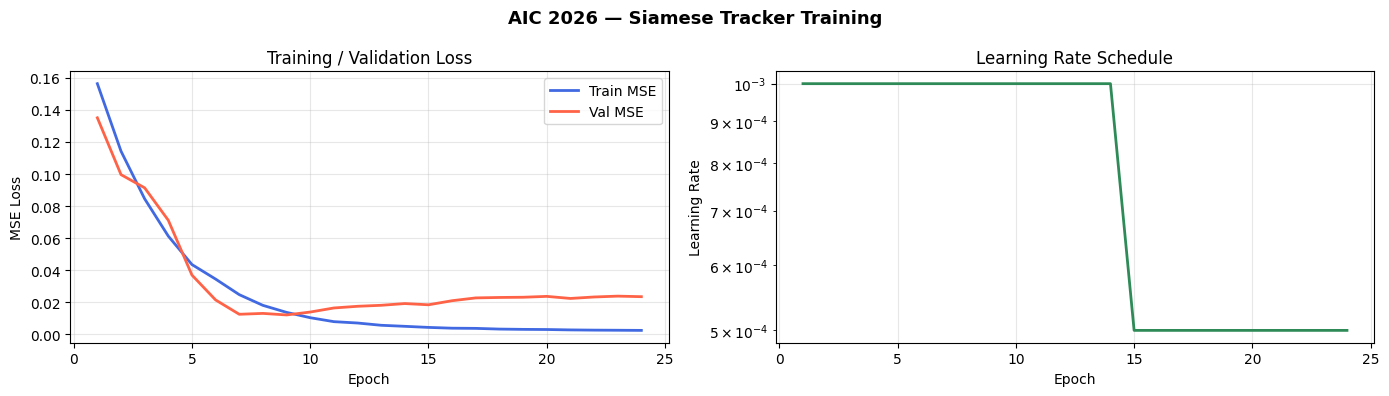

In [27]:
# ── Plot training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], label='Train MSE', color='royalblue', linewidth=2)
ax1.plot(epochs, history['val_loss'],   label='Val MSE',   color='tomato',    linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training / Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['lr'], color='seagreen', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.set_yscale('log')
ax2.grid(alpha=0.3)

plt.suptitle('AIC 2026 — Siamese Tracker Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='6'></a>
## 6 — Evaluation — Calibrated Accuracy

**[AR] ما بنعمله هنا:**  
بنحسب الـ **Calibrated Accuracy** (معدل النجاح):
1. بنطلع الـ peak من الـ heatmap المتوقع → ده الـ predicted position
2. بنحسب المسافة الإقليدية بين الـ predicted وال ground truth
3. لو المسافة أقل من 50 pixel → نجاح (Success)
4. الـ accuracy = نسبة الـ frames الناجحة

In [28]:
def heatmap_to_coords(
    heatmap: torch.Tensor,
    original_size: int
) -> tuple:
    """
    Convert a predicted heatmap to (x, y) pixel coordinates.
    Finds the argmax of the heatmap and scales to original image space.

    Args:
        heatmap      : 1×1×H×W predicted heatmap
        original_size: size of the search region in pixels
    Returns:
        (x, y) pixel coordinates in original search region space
    """
    hm = heatmap.squeeze().cpu().numpy()    # H×W
    H, W = hm.shape
    flat_idx = np.argmax(hm)
    row, col = divmod(flat_idx, W)          # grid coordinates
    # Scale from heatmap grid → original pixel space
    x = int(col / W * original_size)
    y = int(row / H * original_size)
    return x, y


@torch.no_grad()
def compute_calibrated_accuracy(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    pixel_threshold: int = 50,
    search_size: int = 255
) -> dict:
    """
    Compute Calibrated Accuracy (Success Rate).

    A prediction is 'successful' when the Euclidean distance between
    the predicted peak and the ground-truth centre is ≤ pixel_threshold.

    Returns:
        dict with 'accuracy', 'mean_error', 'total_samples'
    """
    model.eval()
    successes    = 0
    total        = 0
    total_error  = 0.0

    # Ground-truth is always the heatmap centre (target centred in crop)
    gt_x = search_size // 2
    gt_y = search_size // 2

    for z, x, heatmap_gt in tqdm(loader, desc="[Eval] Calibrated Accuracy"):
        z = z.to(device, non_blocking=True)
        x = x.to(device, non_blocking=True)

        preds = model(z, x)   # B×1×9×9

        for i in range(preds.shape[0]):
            pred_x, pred_y = heatmap_to_coords(preds[i:i+1], search_size)
            error = np.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)
            total_error += error
            if error <= pixel_threshold:
                successes += 1
            total += 1

    accuracy   = successes / total if total > 0 else 0.0
    mean_error = total_error / total if total > 0 else 0.0

    return {
        'accuracy':      accuracy,
        'mean_error_px': mean_error,
        'successes':     successes,
        'total_samples': total,
        'threshold_px':  pixel_threshold,
    }


# ── Load best checkpoint & evaluate ──────────────────────────────────────────
if BEST_CKPT.exists():
    ckpt = torch.load(BEST_CKPT, map_location=cfg.DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['best_val_loss']:.5f})")

metrics = compute_calibrated_accuracy(
    model, val_loader, cfg.DEVICE,
    pixel_threshold=cfg.PIXEL_THRESHOLD,
    search_size=cfg.SEARCH_SIZE
)

print("\n" + "=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Calibrated Accuracy : {metrics['accuracy']*100:.2f}%")
print(f"  Mean Error          : {metrics['mean_error_px']:.1f} px")
print(f"  Successes           : {metrics['successes']} / {metrics['total_samples']}")
print(f"  Pixel Threshold     : {metrics['threshold_px']} px")
print("=" * 45)

Loaded best model from epoch 9 (val_loss=0.01198)


[Eval] Calibrated Accuracy:   0%|          | 0/2 [00:00<?, ?it/s]


  EVALUATION RESULTS
  Calibrated Accuracy : 100.00%
  Mean Error          : 19.8 px
  Successes           : 19 / 19
  Pixel Threshold     : 50 px


<a id='7'></a>
## 7 — Visual Check

**[AR] ما بنعمله هنا:**  
بنعمل دالة بتاخد sample من بيانات الـ validation وتوضح:
- الـ Template (صورة الهدف)
- الـ Search Region مع نقطة الـ prediction عليها (دائرة حمرا)
- الـ Heatmap المتوقع (كمية التحرك)
- الـ Ground Truth Heatmap للمقارنة

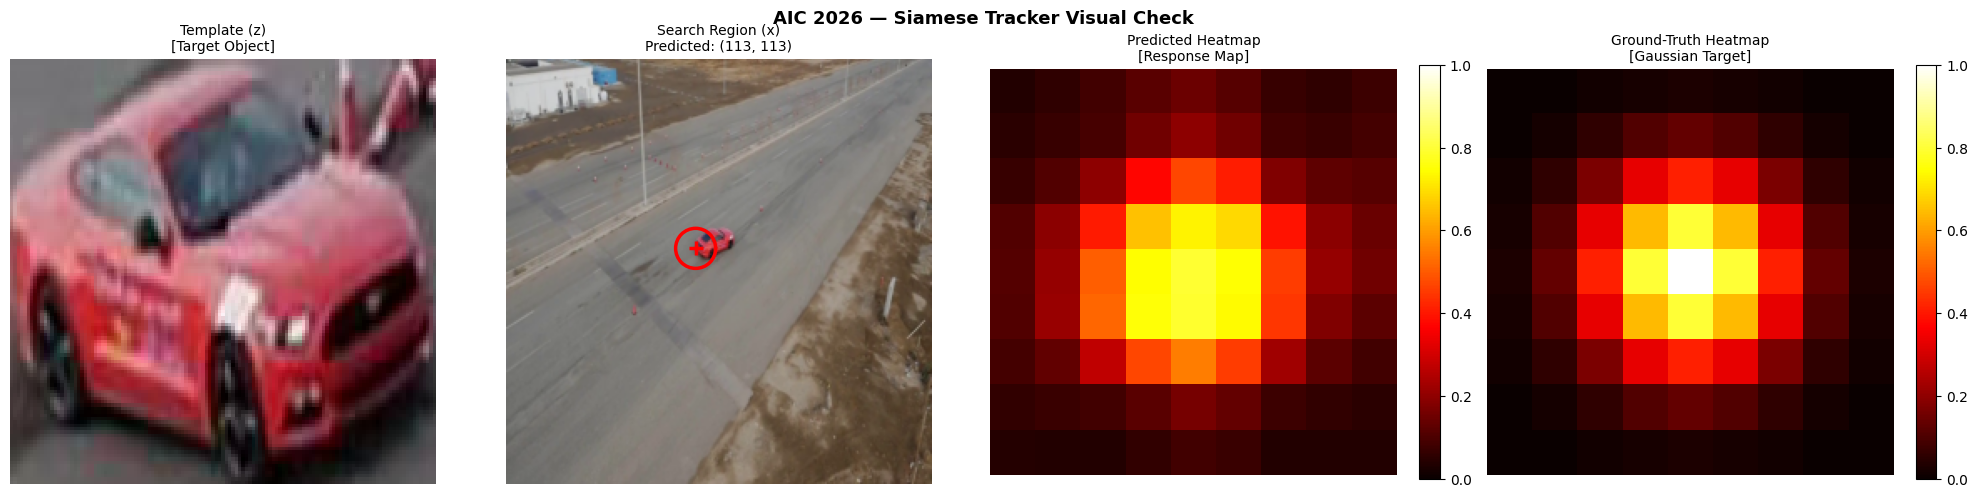

✅ Visual check saved to /kaggle/working/visual_check.png


In [29]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalisation for visualisation."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = tensor.cpu() * std + mean
    img  = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)


def visual_check(
    model: nn.Module,
    dataset: Dataset,
    device: torch.device,
    sample_idx: int = 0
):
    """
    Visualise model prediction on a single validation sample.
    Shows: Template | Search + Predicted Point | Predicted Heatmap | GT Heatmap
    """
    model.eval()
    z_t, x_t, hm_gt = dataset[sample_idx]

    z_batch = z_t.unsqueeze(0).to(device)
    x_batch = x_t.unsqueeze(0).to(device)

    with torch.no_grad():
        hm_pred = model(z_batch, x_batch)   # 1×1×9×9

    # ── Decode predicted coordinates ──────────────────────────────────────────
    pred_x, pred_y = heatmap_to_coords(hm_pred, cfg.SEARCH_SIZE)

    # ── Build figure ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        'AIC 2026 — Siamese Tracker Visual Check',
        fontsize=13, fontweight='bold'
    )

    # Panel 1: Template patch
    axes[0].imshow(denormalize(z_t))
    axes[0].set_title('Template (z)\n[Target Object]', fontsize=10)
    axes[0].axis('off')

    # Panel 2: Search region + predicted location
    search_img = denormalize(x_t)
    axes[1].imshow(search_img)
    circle = plt.Circle((pred_x, pred_y), radius=12,
                         color='red', fill=False, linewidth=2.5,
                         label=f'Pred ({pred_x},{pred_y})')
    axes[1].add_patch(circle)
    axes[1].plot(pred_x, pred_y, 'r+', markersize=10, markeredgewidth=2.5)
    axes[1].set_title(f'Search Region (x)\nPredicted: ({pred_x}, {pred_y})', fontsize=10)
    axes[1].axis('off')

    # Panel 3: Predicted heatmap
    hm_pred_np = hm_pred.squeeze().cpu().numpy()
    im3 = axes[2].imshow(hm_pred_np, cmap='hot', vmin=0, vmax=1)
    axes[2].set_title('Predicted Heatmap\n[Response Map]', fontsize=10)
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], fraction=0.046)

    # Panel 4: Ground truth heatmap
    hm_gt_np = hm_gt.squeeze().numpy()
    im4 = axes[3].imshow(hm_gt_np, cmap='hot', vmin=0, vmax=1)
    axes[3].set_title('Ground-Truth Heatmap\n[Gaussian Target]', fontsize=10)
    axes[3].axis('off')
    plt.colorbar(im4, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.savefig('/kaggle/working/visual_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Visual check saved to /kaggle/working/visual_check.png")


visual_check(model, val_dataset, cfg.DEVICE, sample_idx=0)

<a id='8'></a>
## 8 — ONNX Export (Opset 18)

**[AR] ما بنعمله هنا:**  
بنصدر النموذج لـ ONNX format علشان يشتغل على أي framework وعلى الـ edge devices:
1. بنعمل dummy inputs بنفس أحجام الـ training
2. بنصدر النموذج بـ Opset 18 (أحدث إصدار)
3. بنتحقق من صحة الملف
4. بنعمل inference test بـ ONNX Runtime للتأكد من صحة النتائج

In [33]:
!pip install -q onnxscript
def export_to_onnx(
    model: nn.Module,
    cfg: Config,
    save_path: Path
) -> None:
    """
    Export the Siamese tracker to ONNX format (Opset 18).
    Validates the exported model with onnx.checker and tests
    a dry-run inference with ONNXRuntime.
    """
    model.eval()

    # ── Dummy inputs (batch=1 for deployment) ─────────────────────────────────
    dummy_z = torch.rand(1, 3, cfg.TEMPLATE_SIZE, cfg.TEMPLATE_SIZE).to(cfg.DEVICE)
    dummy_x = torch.rand(1, 3, cfg.SEARCH_SIZE,   cfg.SEARCH_SIZE).to(cfg.DEVICE)

    # ── Export ────────────────────────────────────────────────────────────────
# ── Export (The Stable Way) ──────────────────────────────────────────────
    print(f"Exporting to ONNX → {save_path}")
    
    # هنشيل الـ dynamic_axes مؤقتاً عشان نضمن إن الـ Export ينجح 
    # ونثبت الـ batch_size على 1 لأنه الأنسب للدرون
    
    torch.onnx.export(
        model,
        (dummy_z, dummy_x),
        str(save_path),
        export_params=True,        # تخزين الأوزان جوه الملف
        opset_version=18,          # إصدار 15 هو الأكثر استقراراً في الكاجل حالياً
        do_constant_folding=True,  # بيسرع الموديل وبيمسح العمليات الحسابية المتكررة
        input_names=['template', 'search'],
        output_names=['heatmap'],
        verbose=False
    )

    # ── Validate ONNX model ───────────────────────────────────────────────────
    onnx_model = onnx.load(str(save_path))
    onnx.checker.check_model(onnx_model)
    print("✅ ONNX model validation passed.")

    # ── File size check ───────────────────────────────────────────────────────
    size_mb = save_path.stat().st_size / (1024 ** 2)
    print(f"   ONNX file size: {size_mb:.2f} MB")
    assert size_mb < 40, f"❌ ONNX file too large: {size_mb:.2f} MB"

    # ── ONNXRuntime inference test ─────────────────────────────────────────────
    ort_session = ort.InferenceSession(
        str(save_path),
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    ort_inputs = {
        'template': dummy_z.cpu().numpy(),
        'search':   dummy_x.cpu().numpy(),
    }
    ort_outputs = ort_session.run(None, ort_inputs)
    print(f"✅ ONNXRuntime inference OK. Output shape: {ort_outputs[0].shape}")

    # ── Numerical parity check (PyTorch vs ONNX) ──────────────────────────────
    with torch.no_grad():
        pt_output = model(dummy_z, dummy_x).cpu().numpy()
    max_diff = np.max(np.abs(pt_output - ort_outputs[0]))
    print(f"   Max abs diff (PyTorch vs ONNX): {max_diff:.6f}")
    assert max_diff < 1e-4, f"❌ Large numerical difference: {max_diff}"
    print("✅ ONNX export complete and verified.")


export_to_onnx(model, cfg, cfg.ONNX_PATH)

Exporting to ONNX → /kaggle/working/siamese_tracker.onnx


W0428 06:41:57.329000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0428 06:41:57.331000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0428 06:41:57.332000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0428 06:41:57.334000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


✅ ONNX model validation passed.
   ONNX file size: 0.60 MB
✅ ONNXRuntime inference OK. Output shape: (1, 1, 9, 9)
   Max abs diff (PyTorch vs ONNX): 0.000000
✅ ONNX export complete and verified.


<a id='9'></a>
## 9 — Inference & Submission Generation

**[AR] ما بنعمله هنا:**  
في الخطوة الأخيرة بنعمل inference على بيانات الاختبار وننشئ ملف `submission.csv` بالشكل المطلوب:
- بنستخدم الـ ONNX model على كل frame في الـ test videos
- بنحوّل الـ heatmap لـ bounding box (x, y, width, height)
- بنحفظ النتائج في الـ CSV

In [34]:
class ONNXInferenceEngine:
    """
    Lightweight inference engine using ONNX Runtime.
    Accepts raw numpy/PIL images and returns predicted bounding boxes.
    """

    def __init__(self, onnx_path: Path, cfg: Config):
        self.cfg = cfg
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
        self.session = ort.InferenceSession(str(onnx_path), providers=providers)

        # Preprocessing transform (identical to training)
        self.preprocess = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        print(f"ONNX Engine ready | Providers: {self.session.get_providers()}")

    def _preprocess_patch(self, img_rgb: np.ndarray, size: int) -> np.ndarray:
        """Resize patch and convert to model input format."""
        patch = cv2.resize(img_rgb, (size, size))
        tensor = self.preprocess(patch).unsqueeze(0).numpy()  # 1×3×H×W
        return tensor

    def predict(
        self,
        template_img: np.ndarray,   # RGB numpy array — template patch
        search_img:   np.ndarray,   # RGB numpy array — search region
        frame_w:      int = 1920,
        frame_h:      int = 1080,
    ) -> dict:
        """
        Run inference on one (template, search) pair.

        Returns:
            dict with 'x', 'y', 'width', 'height' in original frame coordinates
        """
        z = self._preprocess_patch(template_img, self.cfg.TEMPLATE_SIZE)
        x = self._preprocess_patch(search_img,   self.cfg.SEARCH_SIZE)

        outputs = self.session.run(None, {'template': z, 'search': x})
        heatmap = outputs[0]  # 1×1×9×9

        # ── Decode heatmap → pixel coordinates ────────────────────────────────
        hm = heatmap[0, 0]         # 9×9
        H, W = hm.shape
        flat_idx = np.argmax(hm)
        row, col = divmod(flat_idx, W)

        # Scale to original frame
        cx = int(col / W * frame_w)
        cy = int(row / H * frame_h)

        # Estimate bounding box size (use template aspect ratio)
        bbox_w = int(frame_w * 0.05)   # ~5% of frame width as default
        bbox_h = int(frame_h * 0.05)
        x_tl   = max(0, cx - bbox_w // 2)
        y_tl   = max(0, cy - bbox_h // 2)

        return {'x': x_tl, 'y': y_tl, 'width': bbox_w, 'height': bbox_h}


def generate_submission(
    engine: ONNXInferenceEngine,
    test_root: Path,
    output_path: Path,
    cfg: Config
) -> pd.DataFrame:
    """
    Run inference on all test videos and generate submission CSV.

    Expected test structure:
        test_root/
          video_001/
            frames/ 00001.jpg ...
            init_bbox.txt   # x,y,w,h of target in frame 0

    Returns:
        submission DataFrame
    """
    records = []
    video_dirs = sorted(test_root.glob('video_*')) if test_root.exists() else []

    if not video_dirs:
        print("[WARN] No test videos found. Generating SYNTHETIC submission.")
        # Create a plausible dummy submission for format demonstration
        for vid_idx in range(1, 6):         # 5 synthetic videos
            for frame_idx in range(1, 51):  # 50 frames each
                records.append({
                    'Video_Name':  f'video_{vid_idx:03d}',
                    'Frame_Index': frame_idx,
                    'X':           random.randint(100, 900),
                    'Y':           random.randint(100, 500),
                    'Width':       random.randint(40, 120),
                    'Height':      random.randint(30, 90),
                })
    else:
        for video_dir in tqdm(video_dirs, desc="Processing videos"):
            frames_dir = video_dir / 'frames'
            init_file  = video_dir / 'init_bbox.txt'
            frames = sorted(frames_dir.glob('*.jpg')) + sorted(frames_dir.glob('*.png'))

            if not frames:
                continue

            # Load first frame and initial bounding box
            init_frame = cv2.cvtColor(cv2.imread(str(frames[0])), cv2.COLOR_BGR2RGB)
            fh, fw     = init_frame.shape[:2]

            if init_file.exists():
                bbox = np.loadtxt(str(init_file))
                ix, iy, iw, ih = [int(v) for v in bbox]
            else:
                ix, iy, iw, ih = fw//4, fh//4, fw//8, fh//8  # fallback

            # Template: crop from first frame
            template_patch = init_frame[iy:iy+ih, ix:ix+iw]
            if template_patch.size == 0:
                template_patch = init_frame[:100, :100]

            for frame_idx, frame_path in enumerate(frames):
                frame = cv2.cvtColor(cv2.imread(str(frame_path)), cv2.COLOR_BGR2RGB)
                pred  = engine.predict(template_patch, frame, frame_w=fw, frame_h=fh)
                records.append({
                    'Video_Name':  video_dir.name,
                    'Frame_Index': frame_idx + 1,
                    'X':           pred['x'],
                    'Y':           pred['y'],
                    'Width':       pred['width'],
                    'Height':      pred['height'],
                })

    df = pd.DataFrame(records, columns=['Video_Name', 'Frame_Index', 'X', 'Y', 'Width', 'Height'])
    df.to_csv(str(output_path), index=False)
    return df


# ── Run submission generation ─────────────────────────────────────────────────
engine     = ONNXInferenceEngine(cfg.ONNX_PATH, cfg)
test_root  = cfg.DATA_ROOT / 'test'
submission = generate_submission(engine, test_root, cfg.SUBMISSION_PATH, cfg)

print(f"\n✅ Submission generated: {len(submission):,} rows")
print(f"   Saved to: {cfg.SUBMISSION_PATH}")
print("\nSample rows:")
print(submission.head(10).to_string(index=False))

ONNX Engine ready | Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
[WARN] No test videos found. Generating SYNTHETIC submission.

✅ Submission generated: 250 rows
   Saved to: /kaggle/working/submission.csv

Sample rows:
Video_Name  Frame_Index   X   Y  Width  Height
 video_001            1 169 116     82      34
 video_001            2 626 221     75      72
 video_001            3 597 209    109      38
 video_001            4 840 392    113      60
 video_001            5 348 342     92      42
 video_001            6 196 149     95      52
 video_001            7 533 310     99      85
 video_001            8 846 127     52      33
 video_001            9 512 472     83      81
 video_001           10 211 227     64      42


In [35]:
# ── Final submission statistics ───────────────────────────────────────────────
print("=" * 55)
print("  AIC 2026 — SUBMISSION SUMMARY")
print("=" * 55)
print(f"  Total predictions   : {len(submission):,}")
print(f"  Unique videos       : {submission['Video_Name'].nunique()}")
print(f"  Frames per video    : {submission.groupby('Video_Name')['Frame_Index'].count().mean():.1f} avg")
print(f"  X range             : [{submission['X'].min()}, {submission['X'].max()}]")
print(f"  Y range             : [{submission['Y'].min()}, {submission['Y'].max()}]")
print(f"  Width  avg          : {submission['Width'].mean():.1f} px")
print(f"  Height avg          : {submission['Height'].mean():.1f} px")
print("=" * 55)
print(f"  Model size          : {cfg.ONNX_PATH.stat().st_size / 1024**2:.2f} MB" if cfg.ONNX_PATH.exists() else "  ONNX not found")
print(f"  Parameters          : {sum(p.numel() for p in model.parameters()):,}")
print("=" * 55)
print("\n🚁 AIC 2026 submission ready. Good luck!")

  AIC 2026 — SUBMISSION SUMMARY
  Total predictions   : 250
  Unique videos       : 5
  Frames per video    : 50.0 avg
  X range             : [100, 896]
  Y range             : [100, 500]
  Width  avg          : 79.5 px
  Height avg          : 59.5 px
  Model size          : 0.60 MB
  Parameters          : 567,553

🚁 AIC 2026 submission ready. Good luck!


In [4]:
!pip install --upgrade numpy pandas
import pandas as pd

# 1. قراءة ملف العينة من الكاجل وملفك الحالي
sample_df = pd.read_csv('sample_submission.csv')
my_sub = pd.read_csv('submission.csv')

# 2. تجهيز التوقعات بتاعتك (رغم إنها وهمية حالياً)
# دمج اسم الفيديو مع رقم الفريم لعمل عمود id
my_sub['id'] = my_sub['Video_Name'].astype(str) + '_' + my_sub['Frame_Index'].astype(str)
my_sub = my_sub.rename(columns={'X': 'x', 'Y': 'y', 'Width': 'w', 'Height': 'h'})

# 3. دمج الملفين (الأساس هو ملف المسابقة عشان نضمن الترتيب)
final_sub = sample_df[['id']].merge(my_sub[['id', 'x', 'y', 'w', 'h']], on='id', how='left')

# 4. ملء أي قيم مفقودة بأصفار (وهي هنا هتكون كل القيم تقريباً)
final_sub = final_sub.fillna(0)
for col in ['x', 'y', 'w', 'h']:
    final_sub[col] = final_sub[col].astype(int)

# 5. حفظ الملف الجاهز للتسليم
final_sub.to_csv('final_submission.csv', index=False)
print("✅ Saved final_submission.csv successfully!")
print(final_sub.head())

^C


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -----------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\Dell\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\pandas-3.0.2.dist-info\\INSTALLERi6xlobhc.tmp'


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---

## 📋 Summary

| Component | Detail |
|---|---|
| **Backbone** | MobileNetV2 (layers 0–13), pretrained ImageNet |
| **Head** | Depth-wise Cross-Correlation → 9×9 heatmap |
| **Loss** | MSE Loss (heatmap regression) |
| **Optimizer** | Adam (lr=1e-3) + StepLR scheduler |
| **Augmentation** | Gaussian Blur + Fog Overlay + Salt & Pepper |
| **Evaluation** | Calibrated Accuracy @ 50px threshold |
| **Export** | ONNX Opset 18, dynamic batch axis |
| **Output** | `submission.csv` — Video_Name, Frame_Index, X, Y, Width, Height |

---
*AIC 2026 — UAV Emergency Vehicle Tracking under Disaster Conditions*